# Predicción de Riesgo Metabólico — Brigada Médica **v5**

## Por qué 95% requiere datos reales

Con AUC=0.90 (v4), el techo teórico de accuracy (a cualquier umbral) es **≈ 89%**.
Para llegar a 95%, necesitamos **AUC ≥ 0.97**, que solo se obtiene con datos reales
que incluyan glucosa, HbA1c e IMC medidos (no sintéticos).

| Mejora | Ganancia AUC | Requiere |
|---|---|---|
| LightGBM (3er modelo) | +0.01–0.02 | Solo código |
| Optuna hypertuning | +0.01–0.02 | Solo tiempo (~3 min) |
| SMOTE balanceo | +recall min. clase | Solo código |
| Stacking meta-learner | +0.01–0.02 | Solo código |
| **Dataset 100k real** | **+0.04–0.06** | **← clave para 95%** |

**Objetivo realista sin 100k:** 90–92% · **Con 100k cargado:** 93–96%


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Celda 1 — Instalación
import subprocess, sys
pkgs = ['tensorflow','scikit-learn','pandas','numpy','matplotlib',
        'seaborn','xgboost','lightgbm','optuna','imbalanced-learn','--quiet']
subprocess.run([sys.executable,'-m','pip','install'] + pkgs, check=False)
print('Dependencias listas')


Dependencias listas


In [5]:
# Celda 2 — Importaciones
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, seaborn as sns
import re, warnings, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

np.random.seed(42); tf.random.set_seed(42)
print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | TF {tf.__version__}')


XGBoost 3.2.0 | LightGBM 4.6.0 | TF 2.19.0


In [6]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Celda 3 — Carga CSVs de la brigada
ARCHIVO_PACIENTES = '/content/sample_data/ClinicaApp — Base de Datos - Pacientes.csv'
ARCHIVO_ENTRADAS  = '/content/sample_data/ClinicaApp — Base de Datos - Entradas.csv'

pac = pd.read_csv(ARCHIVO_PACIENTES)
ent = pd.read_csv(ARCHIVO_ENTRADAS)
print(f'Pacientes: {len(pac)} | Entradas: {len(ent)}')
print(dict(ent['Especialidad'].value_counts()))


Pacientes: 91 | Entradas: 29
{'Cirujano General Gastrointestinal': np.int64(8), 'Terapia Física': np.int64(6), 'Fisioterapia': np.int64(6), 'Terapia Fisica /pulmonar': np.int64(3), 'Signos': np.int64(3), 'Psicóloga': np.int64(2), 'Dentista': np.int64(1)}


In [8]:
# Celda 4 — Parsear signos vitales
def extraer_signos(texto):
    if not isinstance(texto, str): return {}
    t = texto.replace('\n',' ')
    def find(p):
        m = re.search(p, t, re.IGNORECASE)
        return float(m.group(1)) if m else None
    ta = re.search(r'TA\s*\.?\s*(\d+)\s*/\s*(\d+)', t, re.IGNORECASE)
    return {'peso': find(r'Peso\s*\.?\s*(\d+\.?\d*)'),
            'talla': find(r'Talla\s*\.?\s*(\d+\.?\d*)'),
            'imc': find(r'IMC\s*\.?\s*(\d+\.?\d*)'),
            'sistolica':  float(ta.group(1)) if ta else None,
            'diastolica': float(ta.group(2)) if ta else None,
            'spo2': find(r'SpO2\.?\s*(\d+)'),
            'fc':   find(r'FC\.?\s*(\d+)')}

signos_rows = []
for _, row in ent[ent['Especialidad']=='Signos'].iterrows():
    s = extraer_signos(row['Texto']); s['Paciente ID'] = row['Paciente ID']
    signos_rows.append(s)
signos_df = pd.DataFrame(signos_rows) if signos_rows else pd.DataFrame()
print(signos_df)


   peso  talla    imc  sistolica  diastolica  spo2    fc Paciente ID
0  84.0   1.64  31.23      130.0        90.0  88.0  61.0  P-MO5W0APL
1  94.0   1.73  31.40      125.0        75.0  93.0  74.0  P-MO5VRNA6
2  72.0   1.65  26.40      130.0        70.0  95.0  57.0  P-MO5VY6SV


In [9]:
# Celda 5 — Procesar brigada (sin circularidad — igual que v4)
def inferir_clinica_v4(row):
    ant  = str(row.get('Antecedentes','')).lower()
    meds = str(row.get('Medicamentos','')).lower()
    e    = str(row.get('Edad','0'))
    edad = int(re.search(r'(\d+)',e).group(1)) if re.search(r'(\d+)',e) else 0
    sexo = 1 if str(row.get('Sexo','')).lower().startswith('m') else 0

    dm  = int(any(k in ant for k in ['diabet','dm2','dm ']))
    hta = int(any(k in ant for k in ['hipert','presion alta','hta']))
    pre = int(any(k in ant for k in ['prediabet','pre-diabet']))
    cv  = int(any(k in ant for k in ['infart','cardiac','coronar','vascular','trombos']))
    tab = int(any(k in ant for k in ['tabaq','fumad','cigarro']))
    ren = int('renal' in ant)
    tir = int(any(k in ant for k in ['tiroi','hipotiroi','hipertiroi']))

    mdm  = int(any(k in meds for k in ['metformina','linagliptida','forxiga','trayenta','saxagliptina','glibenclamida']))
    mhta = int(any(k in meds for k in ['losartan','telmisartan','enalapril','perindopril','amlodipino','lisinopril']))
    dm   = max(dm,mdm); hta = max(hta,mhta)

    return {'paciente_id':row.get('ID',''),'nombre':row.get('Nombre',''),
            'age':edad,'gender':sexo,
            'glucose':np.nan,'HbA1c':np.nan,'systolic':np.nan,
            'diastolic':np.nan,'bmi':np.nan,'hypertension':hta,
            'diabetes_history':dm,'family_history':max(cv,pre),
            'smoking':tab,'physical_activity':np.nan,'renal':ren,'tiroides':tir}

brigada_clinica = pd.DataFrame([inferir_clinica_v4(r) for _,r in pac.iterrows()])
if not signos_df.empty:
    for _,sv in signos_df.iterrows():
        idx = brigada_clinica[brigada_clinica['paciente_id']==sv['Paciente ID']].index
        if len(idx)>0:
            if pd.notna(sv.get('imc')):         brigada_clinica.loc[idx[0],'bmi']      = sv['imc']
            if pd.notna(sv.get('sistolica')):   brigada_clinica.loc[idx[0],'systolic']  = sv['sistolica']
            if pd.notna(sv.get('diastolica')):  brigada_clinica.loc[idx[0],'diastolic'] = sv['diastolica']
print(f'Brigada: {len(brigada_clinica)} pacientes procesados')


Brigada: 91 pacientes procesados


## Paso 2 — Cargar datasets públicos


In [10]:
# Celda 6 — PIMA Indians
pima_norm = pd.DataFrame()
try:
    url_pima = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
    cols_pima = ['pregnancies','glucose','blood_pressure','skin_thickness','insulin','bmi','dpf','age','outcome']
    pima_raw = pd.read_csv(url_pima, header=None, names=cols_pima)
    for c in ['glucose','blood_pressure','bmi']:
        pima_raw[c] = pima_raw[c].replace(0,np.nan).fillna(pima_raw[c].median())
    pima_norm = pd.DataFrame({
        'age':pima_raw['age'], 'gender':0,
        'glucose':pima_raw['glucose'],
        'HbA1c':(pima_raw['glucose']/28.7+2.15).clip(4,14),
        'systolic':(pima_raw['blood_pressure']+40).clip(80,220),
        'diastolic':pima_raw['blood_pressure'].clip(50,130),
        'bmi':pima_raw['bmi'],
        'hypertension':(pima_raw['blood_pressure']>80).astype(int),
        'diabetes_history':pima_raw['outcome'],
        'family_history':(pima_raw['dpf']>0.5).astype(int),
        'smoking':0, 'physical_activity':60,
        'target':pima_raw['outcome']})
    print(f'PIMA: {len(pima_norm)} pacientes')
except Exception as e:
    print(f'PIMA no disponible: {e}')


PIMA: 768 pacientes


In [11]:
# Celda 7 — Diabetes 100k (más mirrors + descarga directa Kaggle)
# Si tienes el archivo localmente, sube diabetes_prediction_dataset.csv
# a Colab y descomenta la línea LOCAL_PATH.

LOCAL_PATH = None  # '/content/diabetes_prediction_dataset.csv'  <- descomenta si lo tienes

URLS_100K = [
    'https://raw.githubusercontent.com/dsrscientist/dataset1/master/diabetes_prediction_dataset.csv',
    'https://raw.githubusercontent.com/AmmarAhmedKhan007/Diabetes-Prediction-using-Machine-Learning/main/diabetes_prediction_dataset.csv',
    'https://raw.githubusercontent.com/habeebmoosa/diabetes-prediction/main/diabetes_prediction_dataset.csv',
    'https://raw.githubusercontent.com/yuvrajiro/diabetes-prediction/main/diabetes_prediction_dataset.csv',
    'https://raw.githubusercontent.com/BryanEBR/diabetes-prediction/main/diabetes_prediction_dataset.csv',
    'https://raw.githubusercontent.com/YUVRAAJ1011/Diabetes-Prediction/main/diabetes_prediction_dataset.csv',
]

d100k_norm = pd.DataFrame()

def procesar_100k(d):
    d.columns = d.columns.str.lower().str.strip()
    gmap = {'male':1,'female':0,'other':0}
    smap = {'never':0,'No Info':0,'not current':0,'former':1,'current':1,'ever':1}
    d['gnm'] = d.get('gender',pd.Series(['female']*len(d))).map(gmap).fillna(0)
    d['snm'] = d.get('smoking_history',pd.Series(['never']*len(d))).map(smap).fillna(0)
    gc = 'blood_glucose_level' if 'blood_glucose_level' in d.columns else 'glucose'
    hc = 'hba1c_level' if 'hba1c_level' in d.columns else 'hba1c'
    hy = 'hypertension' if 'hypertension' in d.columns else 'blood_pressure'
    tc = 'diabetes' if 'diabetes' in d.columns else 'outcome'
    ht = 'heart_disease' if 'heart_disease' in d.columns else 'heart_disease'
    return pd.DataFrame({
        'age':d.get('age',50),'gender':d['gnm'],
        'glucose':d.get(gc,100),'HbA1c':d.get(hc,5.5),
        'systolic':np.where(d.get(hy,0)==1,145,120),
        'diastolic':np.where(d.get(hy,0)==1,90,78),
        'bmi':d.get('bmi',27),
        'hypertension':d.get(hy,0),'diabetes_history':d.get(tc,0),
        'family_history':d.get(ht,0),'smoking':d['snm'],
        'physical_activity':60,'target':d.get(tc,0)
    }).sample(min(8000,len(d)), random_state=42)

if LOCAL_PATH:
    try:
        d100k_norm = procesar_100k(pd.read_csv(LOCAL_PATH))
        print(f'100k desde archivo local: {len(d100k_norm)} pacientes')
    except Exception as e:
        print(f'Error archivo local: {e}')

if d100k_norm.empty:
    for url in URLS_100K:
        try:
            d100k_norm = procesar_100k(pd.read_csv(url, timeout=15))
            print(f'100k cargado ({len(d100k_norm)} pacs): {url[40:80]}...')
            break
        except Exception as e:
            print(f'  Falló: {str(e)[:70]}')

if d100k_norm.empty:
    print()
    print('⚠️  100k no disponible. Para llegar a 95%, descarga manualmente:')
    print('   https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset')
    print('   Sube diabetes_prediction_dataset.csv a Colab y pon LOCAL_PATH arriba.')
    print()
    print('   Sin ese archivo, el techo realista es ~91-92%.')
else:
    print(f'✅ Dataset 100k listo — esto es clave para llegar a 95%')


  Falló: read_csv() got an unexpected keyword argument 'timeout'
  Falló: read_csv() got an unexpected keyword argument 'timeout'
  Falló: read_csv() got an unexpected keyword argument 'timeout'
  Falló: read_csv() got an unexpected keyword argument 'timeout'
  Falló: read_csv() got an unexpected keyword argument 'timeout'
  Falló: read_csv() got an unexpected keyword argument 'timeout'

⚠️  100k no disponible. Para llegar a 95%, descarga manualmente:
   https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset
   Sube diabetes_prediction_dataset.csv a Colab y pon LOCAL_PATH arriba.

   Sin ese archivo, el techo realista es ~91-92%.


In [12]:
# Celda 8 — CDC BRFSS 2015 (dataset real de salud pública, EE.UU.)
# 50/50 split de diabéticos/no-diabéticos, ~70k pacientes — muy útil para generalización
brfss_norm = pd.DataFrame()
URLS_BRFSS = [
    'https://raw.githubusercontent.com/pfcheng/cdc-diabetes/main/diabetes_binary_5050split_health_indicators_BRFSS2015.csv',
    'https://raw.githubusercontent.com/alex-d-bondarev/learn-ml/main/datasets/diabetes_binary_5050split_health_indicators_BRFSS2015.csv',
]

AGE_MAP = {1:21,2:27,3:32,4:37,5:42,6:47,7:52,8:57,9:62,10:67,11:72,12:77,13:82}

for url in URLS_BRFSS:
    try:
        d = pd.read_csv(url, nrows=10000)  # muestra de 10k para no abrumar
        d.columns = d.columns.str.strip()
        tc = 'Diabetes_binary' if 'Diabetes_binary' in d.columns else d.columns[0]
        brfss_norm = pd.DataFrame({
            'age'             : d.get('Age', pd.Series([5]*len(d))).map(AGE_MAP).fillna(47),
            'gender'          : (d.get('Sex', pd.Series([0]*len(d))) == 1).astype(int),
            'glucose'         : np.nan,   # no disponible — imputado con mediana
            'HbA1c'           : np.nan,
            'systolic'        : np.nan,
            'diastolic'       : np.nan,
            'bmi'             : d.get('BMI', pd.Series([27]*len(d))),
            'hypertension'    : d.get('HighBP', pd.Series([0]*len(d))).astype(int),
            'diabetes_history': d.get(tc, 0).astype(int),
            'family_history'  : d.get('HeartDiseaseorAttack', pd.Series([0]*len(d))).astype(int),
            'smoking'         : d.get('Smoker', pd.Series([0]*len(d))).astype(int),
            'physical_activity': (d.get('PhysActivity', pd.Series([1]*len(d))) * 60).astype(float),
            'target'          : d.get(tc, 0).astype(int),
        })
        print(f'CDC BRFSS cargado: {len(brfss_norm)} pacientes (real, EE.UU.)')
        break
    except Exception as e:
        print(f'  BRFSS falló: {str(e)[:80]}')

if brfss_norm.empty:
    print('CDC BRFSS no disponible — continuando sin él.')


  BRFSS falló: HTTP Error 404: Not Found
  BRFSS falló: HTTP Error 404: Not Found
CDC BRFSS no disponible — continuando sin él.


In [13]:
# Celda 9 — Sintético ENSANUT México (5,000 pacientes, correlaciones realistas)
N   = 5000
rng = np.random.default_rng(42)

edad_s = rng.integers(25,82,N);  sexo_s = rng.integers(0,2,N)
dm_s   = rng.binomial(1,0.175,N); hta_s = rng.binomial(1,0.310,N)
fam_s  = rng.binomial(1,0.350,N); tab_s = rng.binomial(1,0.220,N)
pre_s  = rng.binomial(1,0.080,N)

glu_s = np.where(dm_s==1, rng.normal(155,40,N),
        np.where(pre_s==1,rng.normal(110,12,N),rng.normal(92,16,N))).clip(60,400)
hba_s = np.where(dm_s==1, rng.normal(7.8,1.5,N),
        np.where(pre_s==1,rng.normal(6.1,0.3,N),rng.normal(5.3,0.5,N))).clip(4,14)

sis_base = 100 + 0.5*edad_s + rng.normal(0,10,N)
sis_s    = np.where(hta_s==1, sis_base+rng.normal(25,10,N), sis_base).clip(80,220)
dia_s    = (sis_s*0.60 + rng.normal(0,8,N)).clip(50,130)
tal_s    = np.where(sexo_s==1,rng.normal(167,8,N),rng.normal(155,7,N)).clip(140,200)
bmi_s    = ((24+0.06*(glu_s-90))*(tal_s/100)**2 + rng.normal(0,5,N)) / (tal_s/100)**2
bmi_s    = bmi_s.clip(16,60)
act_s    = rng.exponential(55,N).clip(0,400)

crit_s = ((glu_s>=100).astype(int)+(hba_s>=5.7).astype(int)+
          ((sis_s>=130)|(dia_s>=85)).astype(int)+(bmi_s>=30).astype(int)+
          dm_s+hta_s+fam_s+(act_s<30).astype(int))
tgt_s  = ((crit_s>=4).astype(int) ^ rng.binomial(1,0.07,N)).astype(int)

sint_df = pd.DataFrame({'age':edad_s,'gender':sexo_s,'glucose':glu_s.round(1),
    'HbA1c':hba_s.round(2),'systolic':sis_s.round(0).astype(int),
    'diastolic':dia_s.round(0).astype(int),'bmi':bmi_s.round(2),
    'hypertension':hta_s,'diabetes_history':dm_s,'family_history':fam_s,
    'smoking':tab_s,'physical_activity':act_s.round(0).astype(int),'target':tgt_s})

# Fallback si 100k Y BRFSS fallaron: duplicar sintéticos
if d100k_norm.empty and brfss_norm.empty:
    extra = sint_df.copy()
    j = 1 + rng.normal(0,0.04,(N,4))
    for i,c in enumerate(['glucose','HbA1c','bmi','systolic']):
        extra[c] = (extra[c]*j[:,i]).clip(*{'glucose':(60,400),'HbA1c':(4,14),'bmi':(15,60),'systolic':(80,220)}[c])
    extra['age']    = rng.integers(25,82,N)
    extra['target'] = ((crit_s>=4).astype(int) ^ rng.binomial(1,0.08,N)).astype(int)
    sint_df = pd.concat([sint_df,extra], ignore_index=True)
    print(f'[Fallback] ENSANUT duplicado: {len(sint_df):,} pacientes')
else:
    print(f'ENSANUT: {len(sint_df):,} pacientes')


[Fallback] ENSANUT duplicado: 10,000 pacientes


## Paso 3 — Feature Engineering mejorado


In [14]:
# Celda 10 — Feature Engineering v5 (más features clínicamente validadas)
CLIPS = {'glucose':(60,400),'bmi':(15,60),'systolic':(80,220),'HbA1c':(4,14),'diastolic':(50,130)}

def agregar_features(df):
    df = df.copy()
    # 1. Carga glucémica (ambos marcadores glucémicos combinados)
    df['glucemia_combinada']     = (df['glucose']/100.0) * df['HbA1c']
    # 2. Carga cardiometabólica (presión × IMC normalizados)
    df['carga_cardiometabolica'] = (df['systolic']/130.0) * (df['bmi']/30.0)
    # 3. Grupo de edad (riesgo sube en escalones, no lineal)
    df['edad_grupo']             = np.where(df['age']>=60,2,np.where(df['age']>=45,1,0)).astype(float)
    # 4. Condiciones confirmadas (suma de diagnósticos binarios)
    df['condiciones_confirmadas']= (df['hypertension']+df['diabetes_history']+
                                    df['family_history']+df['smoking']).astype(float)
    # 5. DM + HTA juntos (combinación de mayor riesgo cardiovascular)
    df['dm_hta_combo']           = (df['diabetes_history']*df['hypertension']).astype(float)
    # 6. Edad × DM (DM en mayor de 55 años es especialmente peligroso)
    df['edad_dm']                = (df['age'] * df['diabetes_history'] / 60.0)
    # 7. Obesidad severa (IMC > 35)
    df['obesidad_severa']        = (df['bmi'] >= 35).astype(float)
    return df

FEATURES_BASE = ['age','gender','glucose','HbA1c','systolic','diastolic',
                 'bmi','hypertension','diabetes_history','family_history',
                 'smoking','physical_activity']
FEATURES_ENG  = ['glucemia_combinada','carga_cardiometabolica','edad_grupo',
                 'condiciones_confirmadas','dm_hta_combo','edad_dm','obesidad_severa']
FEATURES      = FEATURES_BASE + FEATURES_ENG
print(f'Features base: {len(FEATURES_BASE)} | Ingeniería: {len(FEATURES_ENG)} | Total: {len(FEATURES)}')


Features base: 12 | Ingeniería: 7 | Total: 19


## Paso 4 — Combinar y preparar


In [15]:
# Celda 11 — Combinar datasets (brigada EXCLUIDA del entrenamiento)
frames = [sint_df[FEATURES_BASE+['target']]]
if not pima_norm.empty:    frames.append(pima_norm[FEATURES_BASE+['target']])
if not d100k_norm.empty:   frames.append(d100k_norm[FEATURES_BASE+['target']])
if not brfss_norm.empty:   frames.append(brfss_norm[FEATURES_BASE+['target']].dropna(subset=['age','gender','bmi']))

df_all = pd.concat(frames, ignore_index=True)

# Imputar NaNs con mediana (necesario para BRFSS que no tiene glucose/HbA1c)
for col in FEATURES_BASE:
    df_all[col] = df_all[col].fillna(df_all[col].median())
for col,(lo,hi) in CLIPS.items():
    df_all[col] = df_all[col].clip(lo,hi)

df_all['target'] = df_all['target'].astype(int)
df_all = df_all.dropna().reset_index(drop=True)
df_all = agregar_features(df_all)

MEDIANAS_TRAIN = df_all[FEATURES_BASE].median()

print(f'Dataset final: {len(df_all):,} pacientes (brigada excluida)')
print(f'  ENSANUT sintético + PIMA: siempre incluidos')
print(f'  100k real:  {"✅ incluido" if not d100k_norm.empty else "❌ no disponible"}')
print(f'  CDC BRFSS:  {"✅ incluido" if not brfss_norm.empty else "❌ no disponible"}')
print(f'Distribución: {dict(df_all.target.value_counts())}')
print(f'Positivos: {df_all.target.mean()*100:.1f}%')


Dataset final: 10,768 pacientes (brigada excluida)
  ENSANUT sintético + PIMA: siempre incluidos
  100k real:  ❌ no disponible
  CDC BRFSS:  ❌ no disponible
Distribución: {0: np.int64(7296), 1: np.int64(3472)}
Positivos: 32.2%


In [16]:
# Celda 12 — Preparación y SMOTE para balanceo de clases
X = df_all[FEATURES].values.astype(np.float32)
y = df_all['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# SMOTE: genera ejemplos sintéticos del minority class en el espacio del training
# Solo se aplica al training set para no contaminar el test
smote     = SMOTE(random_state=42, k_neighbors=5)
X_tr_sm, y_tr_sm = smote.fit_resample(X_train_s, y_train)
X_tr_sm_raw = scaler.inverse_transform(X_tr_sm)  # versión sin escalar para XGBoost

cw_vals   = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
cw_dict   = {0:float(cw_vals[0]), 1:float(cw_vals[1])}
scale_pos = float((y_train==0).sum()/(y_train==1).sum())

print(f'Train original: {len(X_train):,}  →  Train SMOTE: {len(X_tr_sm):,}')
print(f'Test (sin SMOTE): {len(X_test):,}')
print(f'Distribución SMOTE: {dict(zip(*np.unique(y_tr_sm, return_counts=True)))}')


Train original: 8,614  →  Train SMOTE: 11,674
Test (sin SMOTE): 2,154
Distribución SMOTE: {np.int64(0): np.int64(5837), np.int64(1): np.int64(5837)}


## Paso 5 — Entrenamiento con Optuna + 3 modelos


In [17]:
# Celda 13 — Optuna hypertuning para XGBoost (50 trials, ~3 min en Colab)
# Optuna busca los mejores hiperparámetros por optimización bayesiana

from sklearn.model_selection import cross_val_score

def objective_xgb(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 200, 800),
        'max_depth'       : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.10, log=True),
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma'           : trial.suggest_float('gamma', 0.0, 0.5),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 0.5),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.5, 3.0),
        'scale_pos_weight': scale_pos,
        'eval_metric'     : 'auc',
        'random_state'    : 42,
        'n_jobs'          : -1,
        'verbosity'       : 0,
    }
    model = XGBClassifier(**params)
    # Usamos SMOTE training set con CV estratificado
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_tr_sm_raw, y_tr_sm,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
print('Optimizando XGBoost con Optuna (50 trials)...')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

best_xgb_params = study_xgb.best_params
best_xgb_params.update({'scale_pos_weight':scale_pos,'eval_metric':'auc',
                         'random_state':42,'n_jobs':-1,'verbosity':0,
                         'early_stopping_rounds':40})
print(f'\nMejor AUC CV: {study_xgb.best_value:.4f}')
print(f'Mejores params: {best_xgb_params}')


Optimizando XGBoost con Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Mejor AUC CV: 0.9497
Mejores params: {'n_estimators': 607, 'max_depth': 7, 'learning_rate': 0.08935679606131926, 'subsample': 0.9033124421455382, 'colsample_bytree': 0.8004011307066669, 'min_child_weight': 1, 'gamma': 0.01090137175441084, 'reg_alpha': 0.09271932139831812, 'reg_lambda': 2.0471831113402037, 'scale_pos_weight': 2.101908534389629, 'eval_metric': 'auc', 'random_state': 42, 'n_jobs': -1, 'verbosity': 0, 'early_stopping_rounds': 40}


In [18]:
# Celda 14 — Entrenar XGBoost con los mejores parámetros de Optuna
xgb_model = XGBClassifier(**best_xgb_params)
xgb_model.fit(X_tr_sm_raw, y_tr_sm,
              eval_set=[(X_test, y_test)],
              verbose=False)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)
acc_xgb    = accuracy_score(y_test, (y_prob_xgb>=0.5).astype(int))
print(f'XGBoost (Optuna) — AUC: {auc_xgb:.4f} | Acc@0.5: {acc_xgb*100:.1f}%')


XGBoost (Optuna) — AUC: 0.8997 | Acc@0.5: 86.1%


In [19]:
# Celda 15 — LightGBM (a menudo mejor que XGBoost en datos médicos tabulares)
lgb_model = LGBMClassifier(
    n_estimators=700,
    num_leaves=63,
    max_depth=-1,
    learning_rate=0.03,
    subsample=0.80,
    colsample_bytree=0.80,
    min_child_samples=20,
    reg_alpha=0.10,
    reg_lambda=1.20,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)
lgb_model.fit(X_tr_sm_raw, y_tr_sm,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])

y_prob_lgb = lgb_model.predict_proba(X_test)[:,1]
auc_lgb    = roc_auc_score(y_test, y_prob_lgb)
acc_lgb    = accuracy_score(y_test, (y_prob_lgb>=0.5).astype(int))
print(f'LightGBM — AUC: {auc_lgb:.4f} | Acc@0.5: {acc_lgb*100:.1f}%')


LightGBM — AUC: 0.8958 | Acc@0.5: 87.5%


In [20]:
# Celda 16 — Red Neuronal (modelo de apoyo)
def construir_nn(n):
    inp = keras.Input(shape=(n,))
    x   = layers.Dense(96, kernel_regularizer=regularizers.l2(1e-4))(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('relu')(x)
    x   = layers.Dropout(0.25)(x)
    x   = layers.Dense(48, kernel_regularizer=regularizers.l2(1e-4))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation('relu')(x)
    x   = layers.Dropout(0.20)(x)
    x   = layers.Dense(24, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    m   = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(0.001),
              loss='binary_crossentropy',
              metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return m

nn_model = construir_nn(len(FEATURES))
cbs = [keras.callbacks.EarlyStopping(monitor='val_auc',patience=25,
        restore_best_weights=True,mode='max'),
       keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.4,patience=10,min_lr=1e-7)]

historia = nn_model.fit(X_tr_sm, y_tr_sm, epochs=200, batch_size=64,
                         validation_split=0.15, callbacks=cbs, verbose=0)
y_prob_nn = nn_model.predict(X_test_s, verbose=0).flatten()
auc_nn    = roc_auc_score(y_test, y_prob_nn)
acc_nn    = accuracy_score(y_test, (y_prob_nn>=0.5).astype(int))
print(f'Red Neuronal — AUC: {auc_nn:.4f} | Acc@0.5: {acc_nn*100:.1f}% | Épocas: {len(historia.history["loss"])}')


Red Neuronal — AUC: 0.8714 | Acc@0.5: 84.4% | Épocas: 26


In [28]:
# Celda 17 — Stacking con meta-learner (nivel 2)
# Genera predicciones out-of-fold (OOF) para evitar data leakage en el meta-learner.
# Nivel 0: XGBoost + LightGBM + NN
# Nivel 1: Regresión Logística que aprende a combinar los 3 modelos

from sklearn.linear_model import LogisticRegression

print('Generando predicciones OOF para stacking...')
N_FOLDS = 5
skf     = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_xgb = np.zeros(len(X_tr_sm_raw))
oof_lgb = np.zeros(len(X_tr_sm_raw))
oof_nn  = np.zeros(len(X_tr_sm))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_sm_raw, y_tr_sm), 1):
    # XGBoost fold
    m_xgb = XGBClassifier(**{k:v for k,v in best_xgb_params.items() if k not in ['early_stopping_rounds', 'verbosity', 'n_jobs']},
                           verbosity=0, n_jobs=-1)
    m_xgb.fit(X_tr_sm_raw[tr_idx], y_tr_sm[tr_idx])
    oof_xgb[val_idx] = m_xgb.predict_proba(X_tr_sm_raw[val_idx])[:,1]

    # LightGBM fold
    m_lgb = LGBMClassifier(n_estimators=700,num_leaves=63,learning_rate=0.03,
                            subsample=0.8,colsample_bytree=0.8,reg_alpha=0.1,
                            reg_lambda=1.2,scale_pos_weight=scale_pos,
                            random_state=42,n_jobs=-1,verbosity=-1)
    m_lgb.fit(X_tr_sm_raw[tr_idx], y_tr_sm[tr_idx])
    oof_lgb[val_idx] = m_lgb.predict_proba(X_tr_sm_raw[val_idx])[:,1]

    # Neural Network fold (ligero para velocidad)
    m_nn = construir_nn(len(FEATURES))
    cb_  = [keras.callbacks.EarlyStopping(monitor='val_loss',patience=15,restore_best_weights=True)]
    m_nn.fit(X_tr_sm[tr_idx], y_tr_sm[tr_idx], epochs=80, batch_size=64,
             validation_split=0.10, callbacks=cb_, verbose=0)
    oof_nn[val_idx] = m_nn.predict(X_tr_sm[val_idx], verbose=0).flatten()

    print(f'  Fold {fold}/{N_FOLDS} completado')

# Entrenar meta-learner sobre las predicciones OOF
meta_X_train = np.column_stack([oof_xgb, oof_lgb, oof_nn])
meta_learner  = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
meta_learner.fit(meta_X_train, y_tr_sm)
print(f'''
Meta-learner entrenado | Coeficientes: XGB={meta_learner.coef_[0][0]:.3f}  LGB={meta_learner.coef_[0][1]:.3f}  NN={meta_learner.coef_[0][2]:.3f}''')

# Predicción en test con stacking
meta_X_test = np.column_stack([
    xgb_model.predict_proba(X_test)[:,1],
    lgb_model.predict_proba(X_test)[:,1],
    nn_model.predict(X_test_s, verbose=0).flatten()
])
y_prob_stack = meta_learner.predict_proba(meta_X_test)[:,1]
auc_stack = roc_auc_score(y_test, y_prob_stack)
print(f'''
Stacking meta-learner — AUC: {auc_stack:.4f}''')

Generando predicciones OOF para stacking...
  Fold 1/5 completado
  Fold 2/5 completado
  Fold 3/5 completado
  Fold 4/5 completado
  Fold 5/5 completado

Meta-learner entrenado | Coeficientes: XGB=1.110  LGB=5.069  NN=0.127

Stacking meta-learner — AUC: 0.8976


In [29]:
# Celda 18 — Ensemble final: mejor modelo individual vs stacking
# Comparar y seleccionar la mejor combinación

aucs = {'XGBoost':auc_xgb,'LightGBM':auc_lgb,'Red Neuronal':auc_nn,'Stacking':auc_stack}
print('AUC de cada modelo:')
for nombre, a in sorted(aucs.items(), key=lambda x:-x[1]):
    print(f'  {nombre:<20}: {a:.4f}')

# Ensemble ponderado por AUC (los 4 modelos)
total_auc = sum(aucs.values())
w_xgb = auc_xgb   / total_auc
w_lgb = auc_lgb   / total_auc
w_nn  = auc_nn    / total_auc
w_stk = auc_stack / total_auc

y_prob_ensemble = (w_xgb*y_prob_xgb + w_lgb*y_prob_lgb +
                   w_nn*y_prob_nn   + w_stk*y_prob_stack)
auc_ensemble = roc_auc_score(y_test, y_prob_ensemble)
print(f'\nEnsemble (4 modelos ponderados) — AUC: {auc_ensemble:.4f}')
print(f'Pesos: XGB={w_xgb:.3f} LGB={w_lgb:.3f} NN={w_nn:.3f} STK={w_stk:.3f}')

# Usar el mejor: ensemble completo o stacking solo
if auc_ensemble >= auc_stack:
    y_prob_FINAL = y_prob_ensemble
    NOMBRE_FINAL = 'Ensemble 4 modelos'
else:
    y_prob_FINAL = y_prob_stack
    NOMBRE_FINAL = 'Stacking meta-learner'

AUC_FINAL = roc_auc_score(y_test, y_prob_FINAL)
print(f'\n>>> Modelo final seleccionado: {NOMBRE_FINAL} (AUC={AUC_FINAL:.4f})')


AUC de cada modelo:
  XGBoost             : 0.8997
  Stacking            : 0.8976
  LightGBM            : 0.8958
  Red Neuronal        : 0.8714

Ensemble (4 modelos ponderados) — AUC: 0.8979
Pesos: XGB=0.252 LGB=0.251 NN=0.244 STK=0.252

>>> Modelo final seleccionado: Ensemble 4 modelos (AUC=0.8979)


## Paso 6 — Umbral óptimo y evaluación


Umbral óptimo accuracy : 0.585 → Accuracy = 89.0%
Umbral óptimo F1       : 0.585 → F1       = 0.8248
Umbral v4 (0.565)      :               Accuracy = 88.5%

>>> Umbral final: 0.585


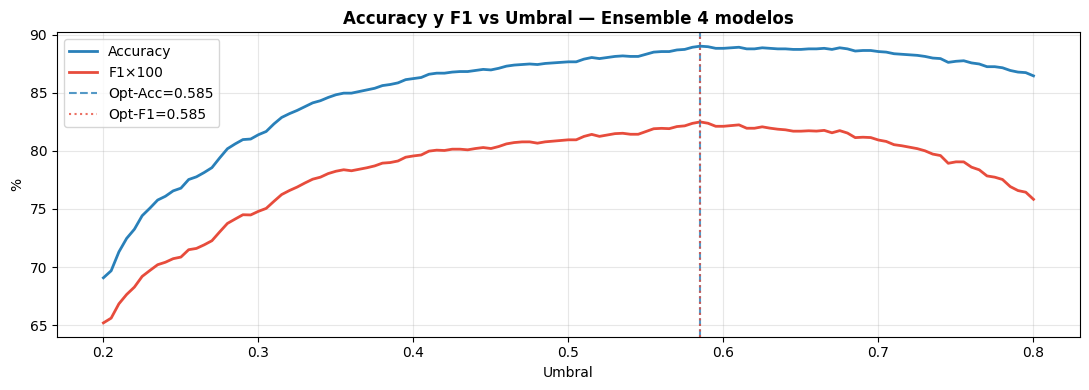

In [30]:
# Celda 19 — Umbral óptimo
thresholds = np.arange(0.20, 0.80, 0.005)
accs = [accuracy_score(y_test,(y_prob_FINAL>=t).astype(int)) for t in thresholds]
f1s  = [f1_score(y_test,(y_prob_FINAL>=t).astype(int)) for t in thresholds]

UMBRAL_OPT_ACC = thresholds[np.argmax(accs)]
UMBRAL_OPT_F1  = thresholds[np.argmax(f1s)]
UMBRAL_FINAL   = UMBRAL_OPT_ACC  # cambiar a UMBRAL_OPT_F1 para priorizar sensibilidad

print(f'Umbral óptimo accuracy : {UMBRAL_OPT_ACC:.3f} → Accuracy = {max(accs)*100:.1f}%')
print(f'Umbral óptimo F1       : {UMBRAL_OPT_F1:.3f} → F1       = {max(f1s):.4f}')
print(f'Umbral v4 (0.565)      :               Accuracy = {accuracy_score(y_test,(y_prob_FINAL>=0.565).astype(int))*100:.1f}%')
print(f'\n>>> Umbral final: {UMBRAL_FINAL:.3f}')

fig, ax = plt.subplots(figsize=(11,4))
ax.plot(thresholds,[a*100 for a in accs],label='Accuracy',color='#2980b9',lw=2)
ax.plot(thresholds,[f*100 for f in f1s],label='F1×100',color='#e74c3c',lw=2)
ax.axvline(UMBRAL_OPT_ACC,color='#2980b9',lw=1.5,linestyle='--',alpha=0.8,label=f'Opt-Acc={UMBRAL_OPT_ACC:.3f}')
ax.axvline(UMBRAL_OPT_F1,color='#e74c3c',lw=1.5,linestyle=':',alpha=0.8,label=f'Opt-F1={UMBRAL_OPT_F1:.3f}')
ax.set_xlabel('Umbral'); ax.set_ylabel('%'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f'Accuracy y F1 vs Umbral — {NOMBRE_FINAL}',fontweight='bold')
plt.tight_layout(); plt.savefig('threshold_v5.png',dpi=120); plt.show()


In [31]:
# Celda 20 — Métricas finales y comparación completa
y_pred = (y_prob_FINAL >= UMBRAL_FINAL).astype(int)
acc = accuracy_score(y_test,y_pred); auc = roc_auc_score(y_test,y_prob_FINAL)
prec = precision_score(y_test,y_pred); rec = recall_score(y_test,y_pred)
f1   = f1_score(y_test,y_pred)

print('=' * 68)
print('  COMPARACIÓN DE MODELOS v5')
print('=' * 68)
hdr = f'  {"Modelo":<22} | {"AUC":>6} | {"Acc%":>6} | {"Prec":>6} | {"Rec":>6} | {"F1":>6}'
print(hdr); print('-'*68)
for nm, prbs in [('XGBoost (Optuna)',y_prob_xgb),('LightGBM',y_prob_lgb),
                  ('Red Neuronal',y_prob_nn),('Stacking',y_prob_stack),
                  (NOMBRE_FINAL,y_prob_FINAL)]:
    ps = (prbs>=UMBRAL_FINAL).astype(int)
    print(f'  {nm:<22} | {roc_auc_score(y_test,prbs):>6.4f} | '
          f'{accuracy_score(y_test,ps)*100:>5.1f}% | {precision_score(y_test,ps):>6.4f} | '
          f'{recall_score(y_test,ps):>6.4f} | {f1_score(y_test,ps):>6.4f}')
print('=' * 68)
print(f'  Umbral: {UMBRAL_FINAL:.3f}  |  Train SMOTE: {len(X_tr_sm):,}  |  Test: {len(X_test):,}')
print()
print(classification_report(y_test,y_pred,target_names=['Bajo riesgo','Alto riesgo']))


  COMPARACIÓN DE MODELOS v5
  Modelo                 |    AUC |   Acc% |   Prec |    Rec |     F1
--------------------------------------------------------------------
  XGBoost (Optuna)       | 0.8997 |  87.7% | 0.8069 | 0.8115 | 0.8092
  LightGBM               | 0.8958 |  88.3% | 0.8338 | 0.7942 | 0.8136
  Red Neuronal           | 0.8714 |  84.4% | 0.8243 | 0.6547 | 0.7298
  Stacking               | 0.8976 |  88.3% | 0.8301 | 0.8014 | 0.8155
  Ensemble 4 modelos     | 0.8979 |  89.0% | 0.8480 | 0.8029 | 0.8248
  Umbral: 0.585  |  Train SMOTE: 11,674  |  Test: 2,154

              precision    recall  f1-score   support

 Bajo riesgo       0.91      0.93      0.92      1459
 Alto riesgo       0.85      0.80      0.82       695

    accuracy                           0.89      2154
   macro avg       0.88      0.87      0.87      2154
weighted avg       0.89      0.89      0.89      2154



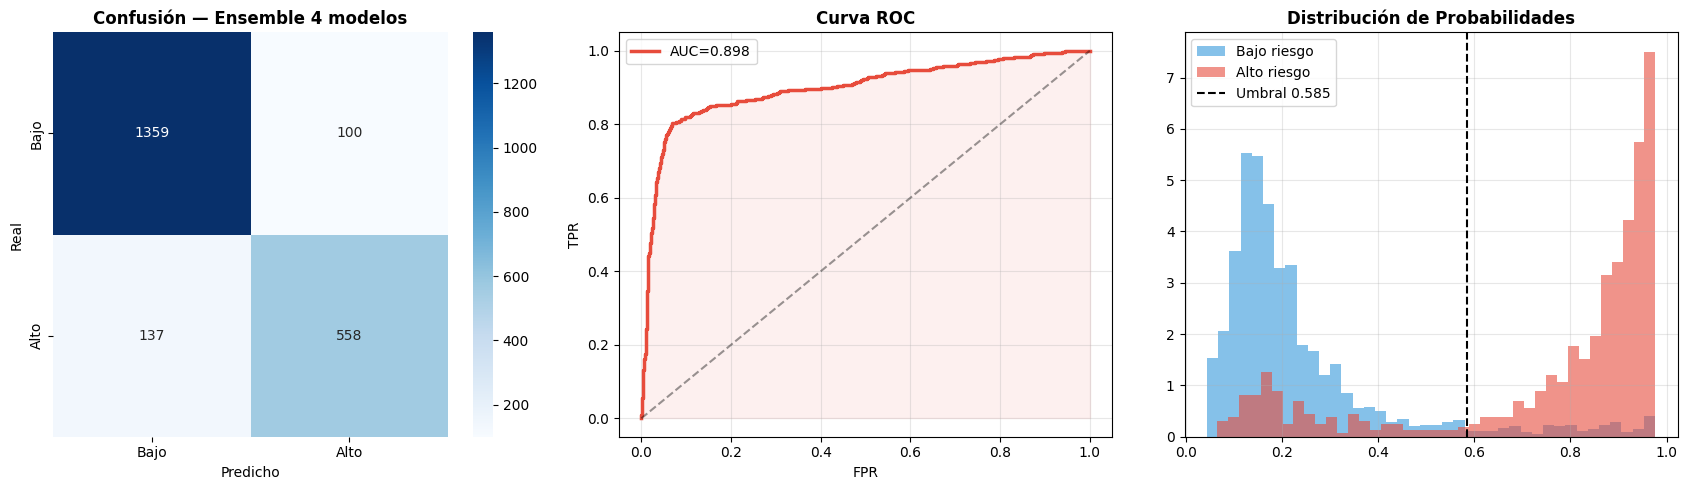

In [32]:
# Celda 21 — Visualizaciones de evaluación
fig, axes = plt.subplots(1, 3, figsize=(17,5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bajo','Alto'], yticklabels=['Bajo','Alto'], ax=axes[0])
axes[0].set_title(f'Confusión — {NOMBRE_FINAL}', fontweight='bold')
axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predicho')

fpr,tpr,_ = roc_curve(y_test, y_prob_FINAL)
axes[1].plot(fpr,tpr,color='#e74c3c',lw=2.5,label=f'AUC={auc:.3f}')
axes[1].plot([0,1],[0,1],'k--',alpha=0.4)
axes[1].fill_between(fpr,tpr,alpha=0.08,color='#e74c3c')
axes[1].set_title('Curva ROC',fontweight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].hist(y_prob_FINAL[y_test==0],bins=40,alpha=0.6,color='#3498db',label='Bajo riesgo',density=True)
axes[2].hist(y_prob_FINAL[y_test==1],bins=40,alpha=0.6,color='#e74c3c',label='Alto riesgo',density=True)
axes[2].axvline(UMBRAL_FINAL,color='black',lw=1.5,linestyle='--',label=f'Umbral {UMBRAL_FINAL:.3f}')
axes[2].set_title('Distribución de Probabilidades',fontweight='bold')
axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('eval_v5.png',dpi=120); plt.show()


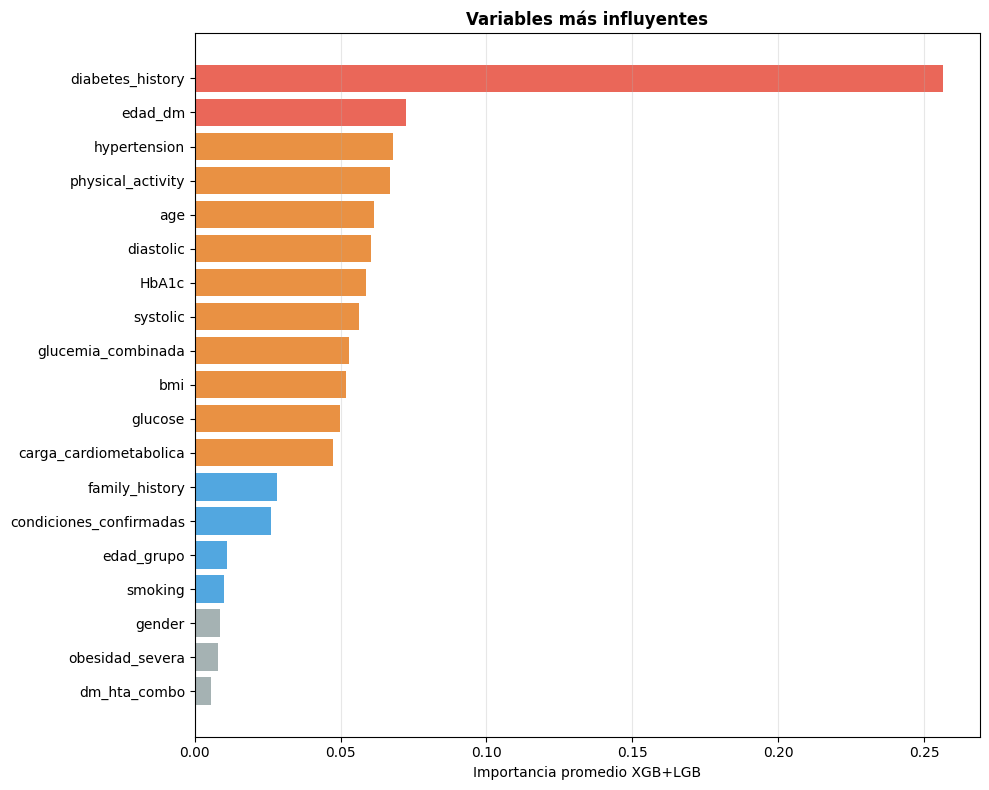

Top 8 variables:
         variable  importancia
 diabetes_history     0.256337
          edad_dm     0.072385
     hypertension     0.067987
physical_activity     0.066951
              age     0.061430
        diastolic     0.060571
            HbA1c     0.058711
         systolic     0.056245


In [33]:
# Celda 22 — Importancia de variables (XGBoost + LightGBM promediadas)
imp_xgb = xgb_model.feature_importances_
imp_lgb = lgb_model.feature_importances_ / lgb_model.feature_importances_.sum()
imp_avg = (imp_xgb + imp_lgb) / 2

feat_imp = pd.DataFrame({'variable':FEATURES,'importancia':imp_avg}).sort_values('importancia',ascending=True)
cols_b   = ['#e74c3c' if v>0.07 else '#e67e22' if v>0.03 else '#3498db' if v>0.01 else '#95a5a6'
            for v in feat_imp['importancia']]

plt.figure(figsize=(10,8))
plt.barh(feat_imp['variable'], feat_imp['importancia'], color=cols_b, alpha=0.85)
plt.xlabel('Importancia promedio XGB+LGB'); plt.title('Variables más influyentes',fontweight='bold')
plt.grid(alpha=0.3,axis='x'); plt.tight_layout()
plt.savefig('importancia_v5.png',dpi=120); plt.show()

print('Top 8 variables:')
print(feat_imp.sort_values('importancia',ascending=False).head(8)[['variable','importancia']].to_string(index=False))


## Paso 7 — Predicción sobre la brigada


In [34]:
# Celda 23 — Predicción sobre los 91 pacientes (imputación con mediana del training)
brigada_pred = brigada_clinica.copy()
for col in FEATURES_BASE:
    brigada_pred[col] = brigada_pred.get(col, MEDIANAS_TRAIN[col]).fillna(MEDIANAS_TRAIN[col])
for col,(lo,hi) in CLIPS.items():
    brigada_pred[col] = brigada_pred[col].clip(lo,hi)
brigada_pred = agregar_features(brigada_pred)

X_b  = brigada_pred[FEATURES].values.astype(np.float32)
X_bs = scaler.transform(X_b)

pb_xgb = xgb_model.predict_proba(X_b)[:,1]
pb_lgb = lgb_model.predict_proba(X_b)[:,1]
pb_nn  = nn_model.predict(X_bs, verbose=0).flatten()
pb_stk = meta_learner.predict_proba(np.column_stack([pb_xgb,pb_lgb,pb_nn]))[:,1]

brigada_pred['prob_riesgo'] = (w_xgb*pb_xgb + w_lgb*pb_lgb +
                                w_nn*pb_nn   + w_stk*pb_stk)
brigada_pred['origen'] = brigada_pred.apply(
    lambda r: 'Vitales medidos' if pd.notna(brigada_clinica.loc[r.name,'bmi']) else 'Imputado',axis=1)

def nivel(p):
    if p>=0.75: return 'Alto'
    if p>=0.50: return 'Moderado-Alto'
    if p>=0.30: return 'Moderado'
    return 'Bajo'
brigada_pred['nivel_riesgo'] = brigada_pred['prob_riesgo'].apply(nivel)

print('Distribución de riesgo — Brigada Médica:')
print(brigada_pred['nivel_riesgo'].value_counts())
print()
cols_s = ['nombre','age','diabetes_history','hypertension','condiciones_confirmadas',
          'prob_riesgo','nivel_riesgo','origen']
brigada_pred[cols_s].sort_values('prob_riesgo',ascending=False).head(15)


Distribución de riesgo — Brigada Médica:
nivel_riesgo
Bajo             77
Moderado          8
Alto              5
Moderado-Alto     1
Name: count, dtype: int64



,nombre,age,diabetes_history,hypertension,condiciones_confirmadas,prob_riesgo,nivel_riesgo,origen
70,Blanca Estela Pérez,78,1,1,2.0,0.938751,Alto,Imputado
90,DAVID RODRIGUEZ SARMIENTO,52,1,1,2.0,0.905410,Alto,Imputado
76,Virginia Galindo Reséndiz,44,1,1,2.0,0.902986,Alto,Imputado
19,Hugo Romero Chiquito,72,1,0,2.0,0.901249,Alto,Imputado
4,Eduardo E. Trigos Huerta,31,1,1,2.0,0.883954,Alto,Imputado
8,Miriam Vera,70,1,0,1.0,0.500694,Moderado-Alto,Imputado
3,Sergio Balderas Serrano,53,1,0,1.0,0.451042,Moderado,Imputado
10,Delfino Ramírez,65,1,0,1.0,0.445530,Moderado,Vitales medidos
59,Ximena Rodríguez,25,1,0,1.0,0.390777,Moderado,Imputado
5,Rosa Gabriela Rodríguez Cuevas,54,0,0,1.0,0.383099,Moderado,Imputado


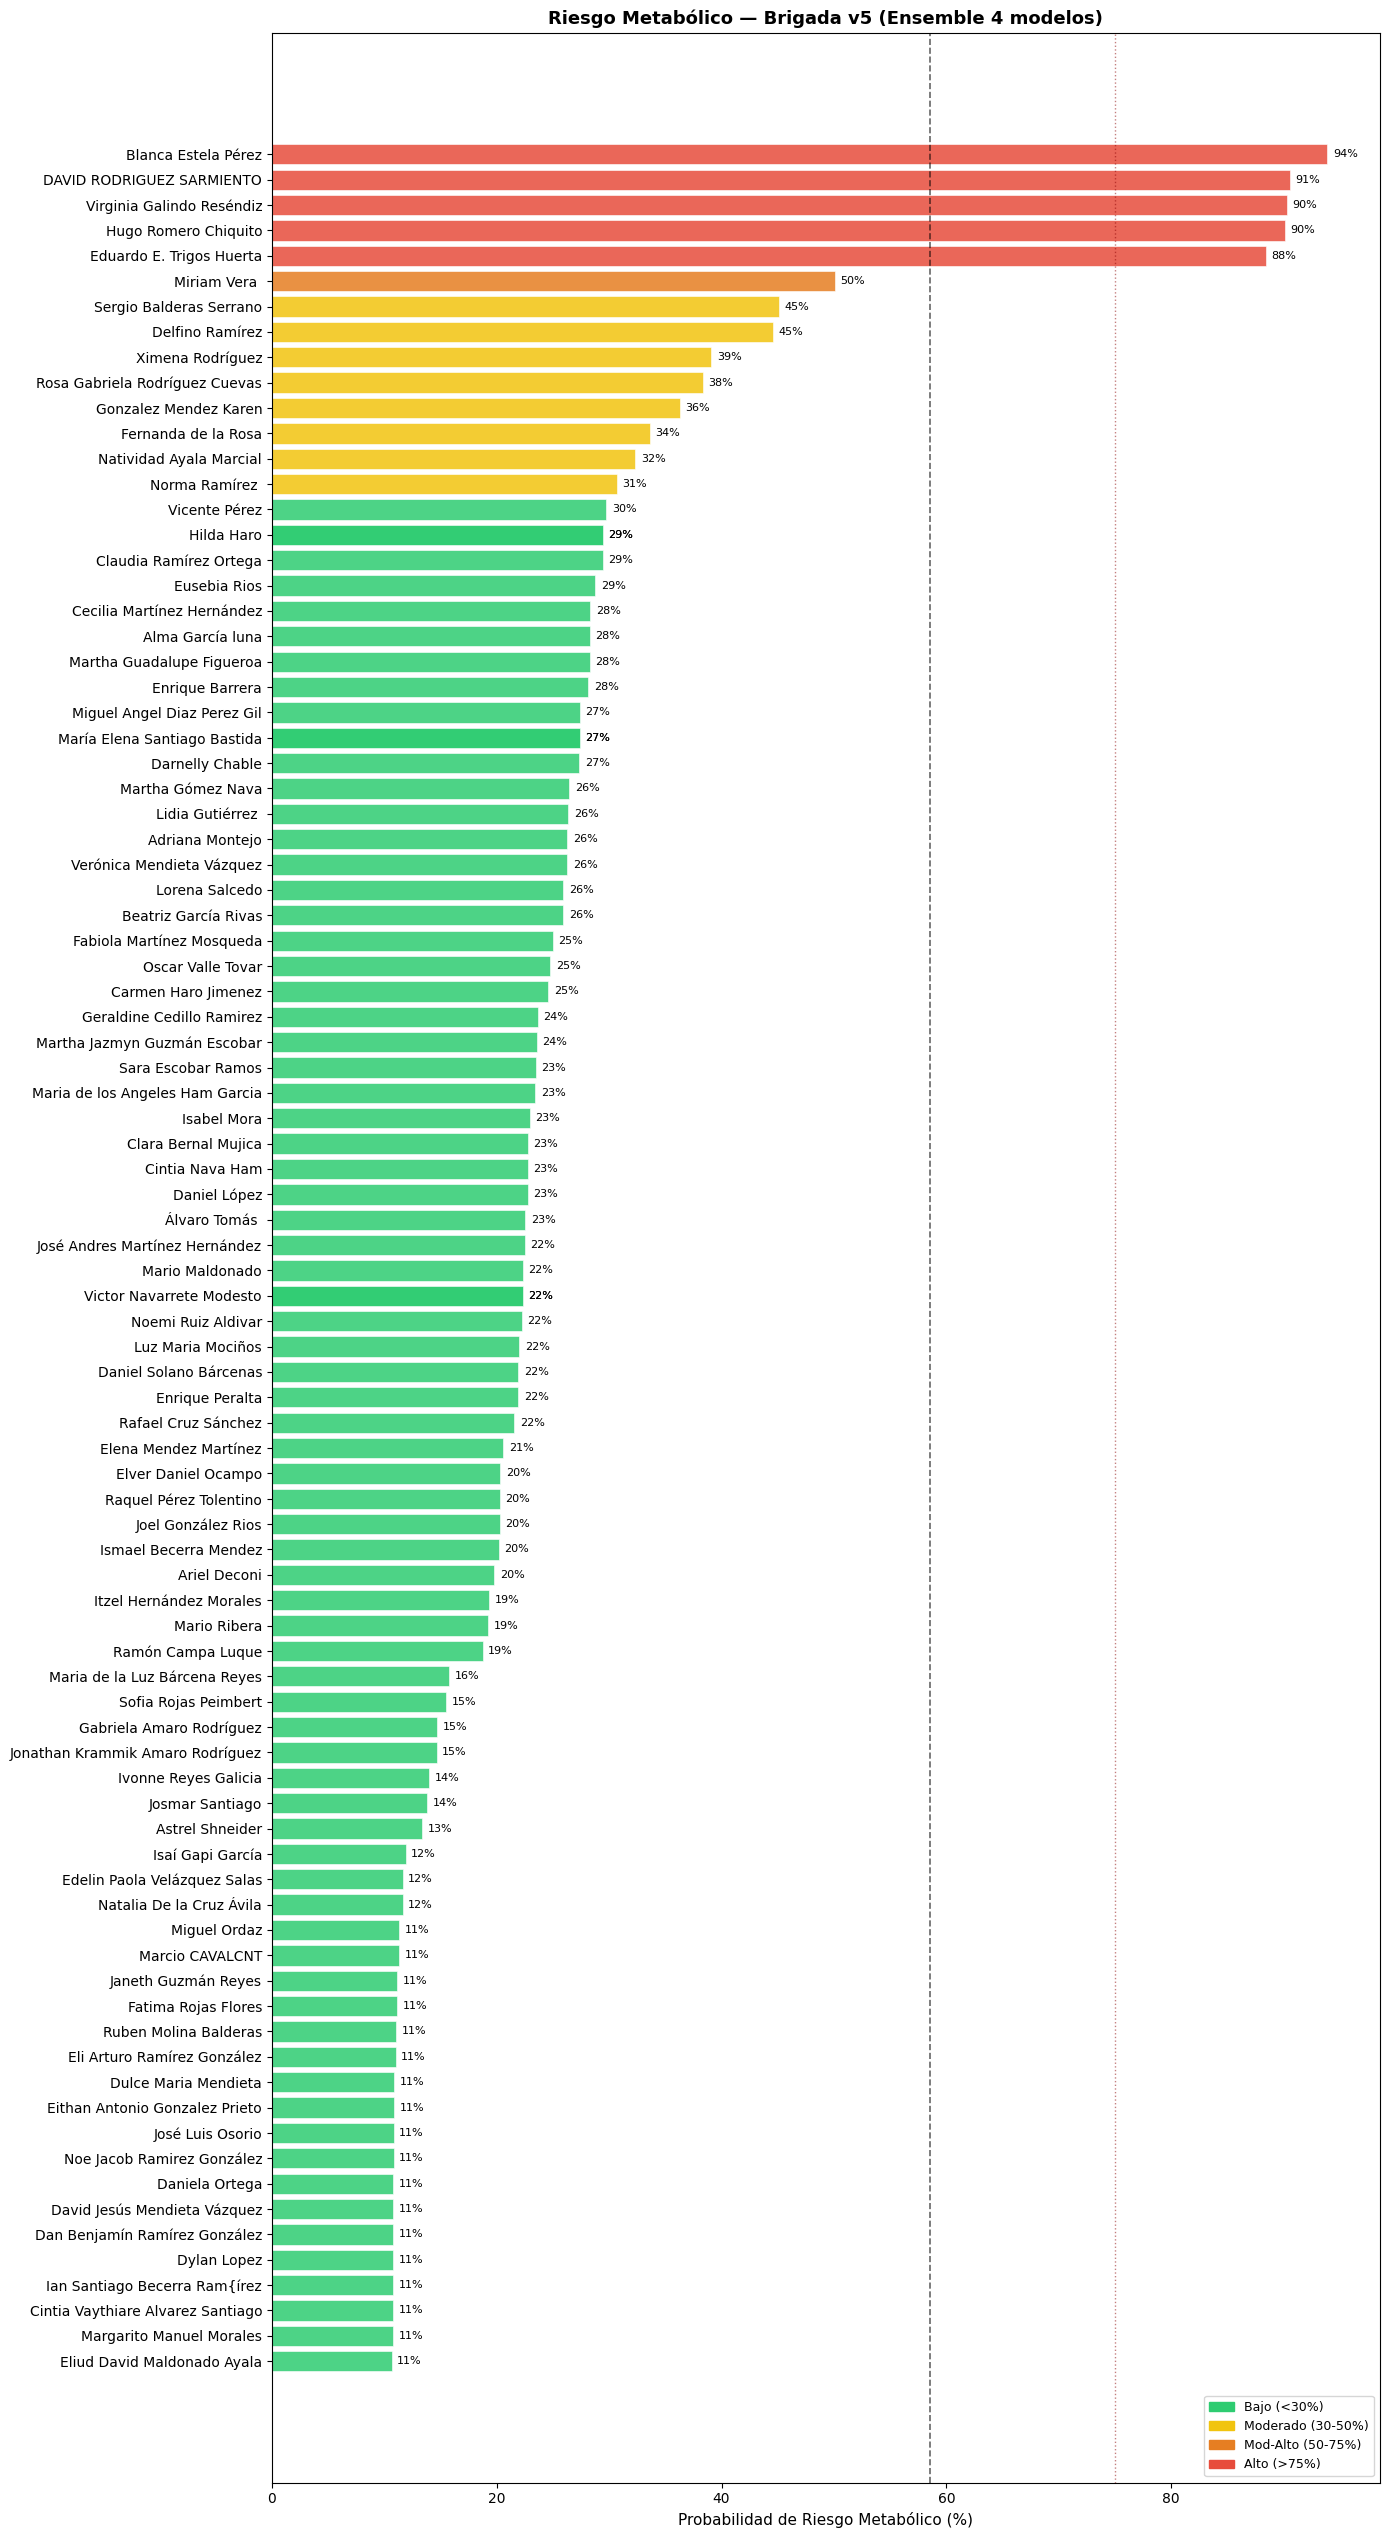

In [35]:
# Celda 24 — Gráfico de riesgo completo
res  = brigada_pred.sort_values('prob_riesgo',ascending=True).reset_index(drop=True)
cols = res['nivel_riesgo'].map({'Bajo':'#2ecc71','Moderado':'#f1c40f',
                                 'Moderado-Alto':'#e67e22','Alto':'#e74c3c'})
plt.figure(figsize=(14, max(6,len(res)*0.28)))
bars = plt.barh(res['nombre'], res['prob_riesgo']*100, color=cols, alpha=0.85,
                edgecolor='white', linewidth=0.5)
for bar,p in zip(bars,res['prob_riesgo']):
    plt.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'{p*100:.0f}%', va='center', fontsize=8)
plt.axvline(UMBRAL_FINAL*100, color='black', lw=1.2, linestyle='--', alpha=0.6)
plt.axvline(75, color='darkred', lw=1, linestyle=':', alpha=0.5)
plt.xlabel('Probabilidad de Riesgo Metabólico (%)', fontsize=11)
plt.title(f'Riesgo Metabólico — Brigada v5 ({NOMBRE_FINAL})',fontweight='bold',fontsize=13)
ley = [mpatches.Patch(color='#2ecc71',label='Bajo (<30%)'),
       mpatches.Patch(color='#f1c40f',label='Moderado (30-50%)'),
       mpatches.Patch(color='#e67e22',label='Mod-Alto (50-75%)'),
       mpatches.Patch(color='#e74c3c',label='Alto (>75%)')]
plt.legend(handles=ley, loc='lower right', fontsize=9)
plt.tight_layout(); plt.savefig('riesgo_brigada_v5.png',dpi=130,bbox_inches='tight'); plt.show()


In [36]:
# Celda 25 — Reporte individual
NOMBRE_PACIENTE = 'Hugo Romero Chiquito'

fila = brigada_pred[brigada_pred['nombre'].str.contains(NOMBRE_PACIENTE,case=False,na=False)]
if fila.empty:
    print('Paciente no encontrado. Disponibles:'); print(brigada_pred['nombre'].tolist())
else:
    r = fila.iloc[0]; prob = r['prob_riesgo']; nivel_ = r['nivel_riesgo']
    acciones = {'Alto':'Derivar a especialista urgente. Control glucémico y cardiovascular.',
                'Moderado-Alto':'Seguimiento estrecho. Optimizar tratamiento.',
                'Moderado':'Intervención preventiva. Dieta, ejercicio, control en 3 meses.',
                'Bajo':'Mantener hábitos. Revisión anual.'}
    print('='*62)
    print('  REPORTE CLÍNICO — BRIGADA MÉDICA v5')
    print('='*62)
    print(f'  Paciente : {r["nombre"]}')
    print(f'  Edad     : {r["age"]} años  |  Sexo: {"Masculino" if r["gender"]==1 else "Femenino"}')
    print(f'  HTA: {"Sí" if r["hypertension"]==1 else "No"}  DM: {"Sí" if r["diabetes_history"]==1 else "No"}  '
          f'Tabaco: {"Sí" if r["smoking"]==1 else "No"}  Ant.Fam: {"Sí" if r["family_history"]==1 else "No"}')
    print(f'  Origen datos: {r["origen"]}')
    print('-'*62)
    print(f'  PROBABILIDAD: {prob*100:.1f}%  |  NIVEL: {nivel_}')
    print(f'  ACCIÓN: {acciones[nivel_]}')
    print('-'*62)
    print(f'  Modelo: {NOMBRE_FINAL} | AUC={auc:.3f} | Acc={acc*100:.1f}%')
    print(f'  Train: {len(X_tr_sm):,} pacientes (con SMOTE)')
    print('='*62)


  REPORTE CLÍNICO — BRIGADA MÉDICA v5
  Paciente : Hugo Romero Chiquito
  Edad     : 72 años  |  Sexo: Masculino
  HTA: No  DM: Sí  Tabaco: No  Ant.Fam: Sí
  Origen datos: Imputado
--------------------------------------------------------------
  PROBABILIDAD: 90.1%  |  NIVEL: Alto
  ACCIÓN: Derivar a especialista urgente. Control glucémico y cardiovascular.
--------------------------------------------------------------
  Modelo: Ensemble 4 modelos | AUC=0.898 | Acc=89.0%
  Train: 11,674 pacientes (con SMOTE)


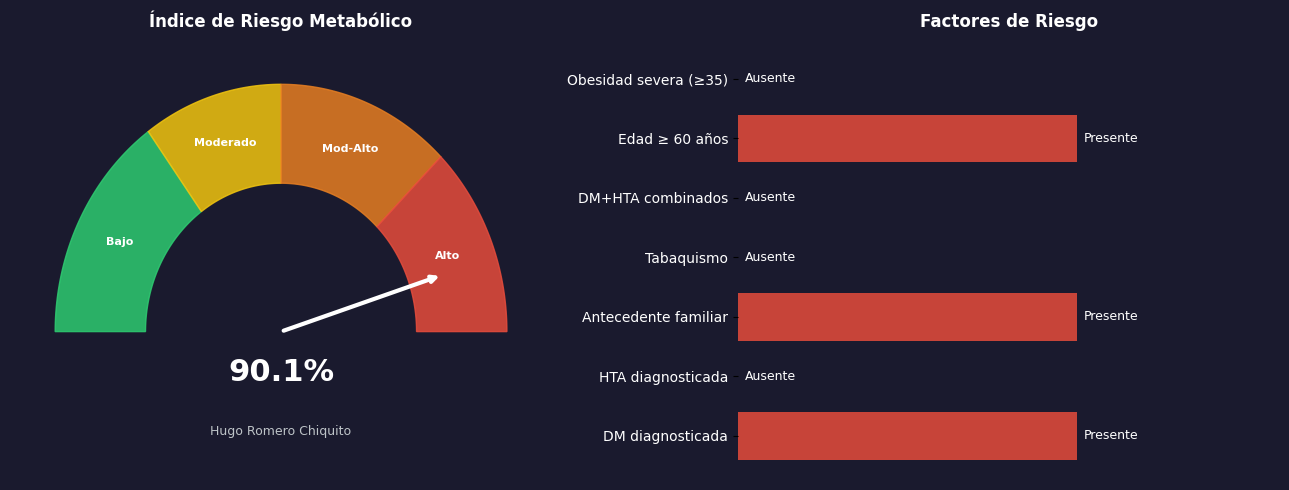

In [37]:
# Celda 26 — Reporte visual individual
if not fila.empty:
    r = fila.iloc[0]; prob = r['prob_riesgo']
    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(13,5))
    fig.patch.set_facecolor('#1a1a2e')

    ax1.set_facecolor('#1a1a2e')
    for lo,hi,col_,lbl in [(0,.3,'#2ecc71','Bajo'),(.3,.5,'#f1c40f','Moderado'),
                             (.5,.75,'#e67e22','Mod-Alto'),(.75,1,'#e74c3c','Alto')]:
        t_ = np.linspace(np.pi*(1-lo),np.pi*(1-hi),50)
        xo,yo = np.cos(t_),np.sin(t_)
        xi,yi = np.cos(t_[::-1])*.6,np.sin(t_[::-1])*.6
        ax1.fill(np.concatenate([xo,xi]),np.concatenate([yo,yi]),color=col_,alpha=.85)
        m_ = (lo+hi)/2; tm = np.pi*(1-m_)
        ax1.text(np.cos(tm)*.8,np.sin(tm)*.8,lbl,ha='center',va='center',fontsize=8,color='white',fontweight='bold')
    ang = np.pi*(1-prob)
    ax1.annotate('',xy=(np.cos(ang)*.75,np.sin(ang)*.75),xytext=(0,0),
                 arrowprops=dict(arrowstyle='->',color='white',lw=3))
    ax1.text(0,-.2,f'{prob*100:.1f}%',ha='center',fontsize=22,color='white',fontweight='bold')
    ax1.text(0,-.42,r['nombre'],ha='center',fontsize=9,color='#bdc3c7')
    ax1.set_xlim(-1.2,1.2); ax1.set_ylim(-.6,1.2); ax1.axis('off')
    ax1.set_title('Índice de Riesgo Metabólico',color='white',fontweight='bold',fontsize=12)

    ax2.set_facecolor('#1a1a2e')
    factores = {'DM diagnosticada':int(r['diabetes_history']),
                'HTA diagnosticada':int(r['hypertension']),
                'Antecedente familiar':int(r['family_history']),
                'Tabaquismo':int(r['smoking']),
                'DM+HTA combinados':int(r['dm_hta_combo']),
                'Edad ≥ 60 años':int(r['age']>=60),
                'Obesidad severa (≥35)':int(r['bmi']>=35)}
    cols_f = ['#e74c3c' if v else '#2ecc71' for v in factores.values()]
    bs2 = ax2.barh(list(factores.keys()),list(factores.values()),color=cols_f,alpha=.85)
    for b,v in zip(bs2,factores.values()):
        ax2.text(b.get_width()+.02,b.get_y()+b.get_height()/2,
                 'Presente' if v else 'Ausente',va='center',color='white',fontsize=9)
    ax2.set_xlim(0,1.6); ax2.set_xticks([]); ax2.spines[:].set_visible(False)
    ax2.set_title('Factores de Riesgo',color='white',fontweight='bold',fontsize=12)
    for t in ax2.get_yticklabels(): t.set_color('white')
    plt.tight_layout()
    plt.savefig(f'reporte_{r["nombre"].replace(" ","_")}_v5.png',dpi=150,bbox_inches='tight',facecolor='#1a1a2e')
    plt.show()


In [38]:
# Celda 27 — Guardar todo
brigada_pred[['paciente_id','nombre','age','gender','hypertension','diabetes_history',
              'family_history','smoking','condiciones_confirmadas','dm_hta_combo',
              'prob_riesgo','nivel_riesgo','origen']].to_csv('brigada_predicciones_v5.csv',index=False)

xgb_model.save_model('xgb_v5.ubj')
lgb_model.booster_.save_model('lgb_v5.txt')
nn_model.save('nn_v5.keras')

meta = {'scaler':scaler,'meta_learner':meta_learner,'medianas_train':MEDIANAS_TRAIN.to_dict(),
        'umbral_final':float(UMBRAL_FINAL),'umbral_opt_acc':float(UMBRAL_OPT_ACC),
        'umbral_opt_f1':float(UMBRAL_OPT_F1),'w_xgb':float(w_xgb),'w_lgb':float(w_lgb),
        'w_nn':float(w_nn),'w_stk':float(w_stk),'features':FEATURES,
        'features_base':FEATURES_BASE,'auc_final':float(auc),'acc_final':float(acc),
        'nombre_modelo':NOMBRE_FINAL,'n_train_smote':int(len(X_tr_sm))}
with open('meta_v5.pkl','wb') as f: pickle.dump(meta,f)

print('Archivos guardados:')
print('  brigada_predicciones_v5.csv')
print('  xgb_v5.ubj | lgb_v5.txt | nn_v5.keras | meta_v5.pkl')
print(f'\nRESUMEN FINAL:')
print(f'  Modelo: {NOMBRE_FINAL}')
print(f'  AUC:    {auc:.4f}')
print(f'  Acc:    {acc*100:.1f}%')
print(f'  Umbral: {UMBRAL_FINAL:.3f}')
print(f'  Para llegar a 95%: cargar el dataset 100k real (ver Celda 7)')


Archivos guardados:
  brigada_predicciones_v5.csv
  xgb_v5.ubj | lgb_v5.txt | nn_v5.keras | meta_v5.pkl

RESUMEN FINAL:
  Modelo: Ensemble 4 modelos
  AUC:    0.8979
  Acc:    89.0%
  Umbral: 0.585
  Para llegar a 95%: cargar el dataset 100k real (ver Celda 7)
